In [31]:
import os
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from PIL import Image
from collections import defaultdict
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
DATA_PATH = "/content/drive/MyDrive/Butterflies/"
TRAIN_DIR = DATA_PATH + "train"
VAL_DIR = DATA_PATH + "valid"
TEST_DIR = DATA_PATH + "test"

In [10]:
print("Train classes:", len(os.listdir(TRAIN_DIR)))
print("Val classes:", len(os.listdir(VAL_DIR)))
print("Test classes:", len(os.listdir(TEST_DIR)))

Train classes: 100
Val classes: 100
Test classes: 100


In [23]:
counts = {}

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        counts[class_name] = num_images

counts

{'ADONIS': 126,
 'AFRICAN GIANT SWALLOWTAIL': 107,
 'APPOLLO': 128,
 'AMERICAN SNOOT': 105,
 'AN 88': 121,
 'BANDED ORANGE HELICONIAN': 139,
 'ATLAS MOTH': 129,
 'ATALA': 143,
 'ARCIGERA FLOWER MOTH': 140,
 'BANDED TIGER MOTH': 136,
 'BECKERS WHITE': 116,
 'BANDED PEACOCK': 118,
 'BLACK HAIRSTREAK': 121,
 'BIRD CHERRY ERMINE MOTH': 133,
 'BLUE MORPHO': 107,
 'BLUE SPOTTED CROW': 123,
 'BROOKES BIRDWING': 165,
 'BROWN SIPROETA': 140,
 'BROWN ARGUS': 169,
 'CAIRNS BIRDWING': 117,
 'CABBAGE WHITE': 127,
 'CHALK HILL BLUE': 149,
 'CINNABAR MOTH': 131,
 'CHESTNUT': 122,
 'CLEOPATRA': 133,
 'CLEARWING MOTH': 122,
 'CHECQUERED SKIPPER': 136,
 'CLODIUS PARNASSIAN': 122,
 'CLOUDED SULPHUR': 128,
 'COMET MOTH': 105,
 'COMMON WOOD-NYMPH': 128,
 'COMMON BANDED AWL': 123,
 'DANAID EGGFLY': 135,
 'CRIMSON PATCH': 103,
 'CRECENT': 138,
 'COPPER TAIL': 133,
 'EASTERN PINE ELFIN': 136,
 'EASTERN COMA': 132,
 'EASTERN DAPPLE WHITE': 132,
 'ELBOWED PIERROT': 117,
 'GARDEN TIGER MOTH': 131,
 'EMPEROR GUM 

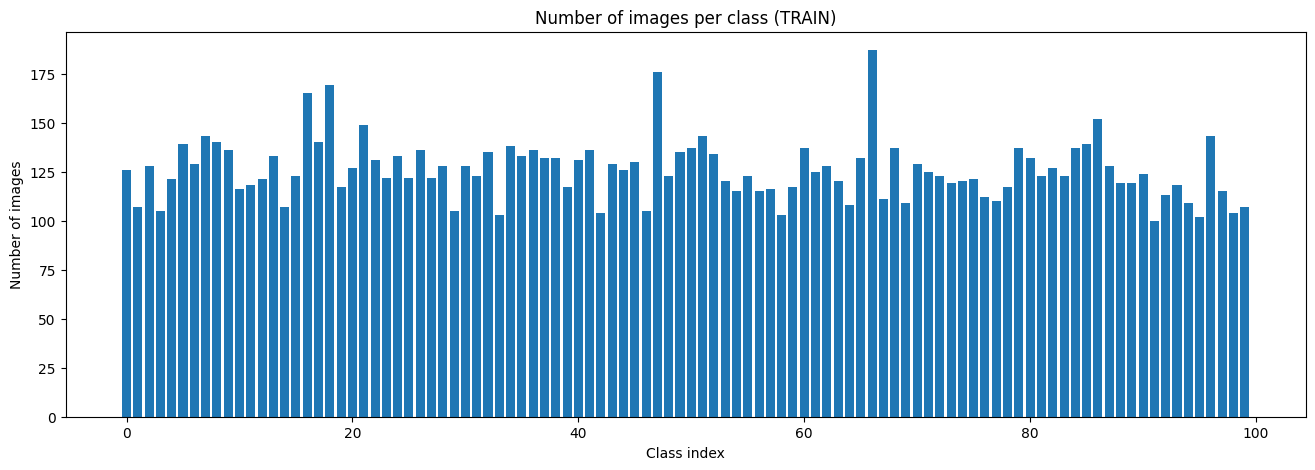

In [25]:
values = list(counts.values())

plt.figure(figsize=(16,5))
plt.bar(range(len(values)), values)
plt.xlabel("Class index")
plt.ylabel("Number of images")
plt.title("Number of images per class (TRAIN)")
plt.show()

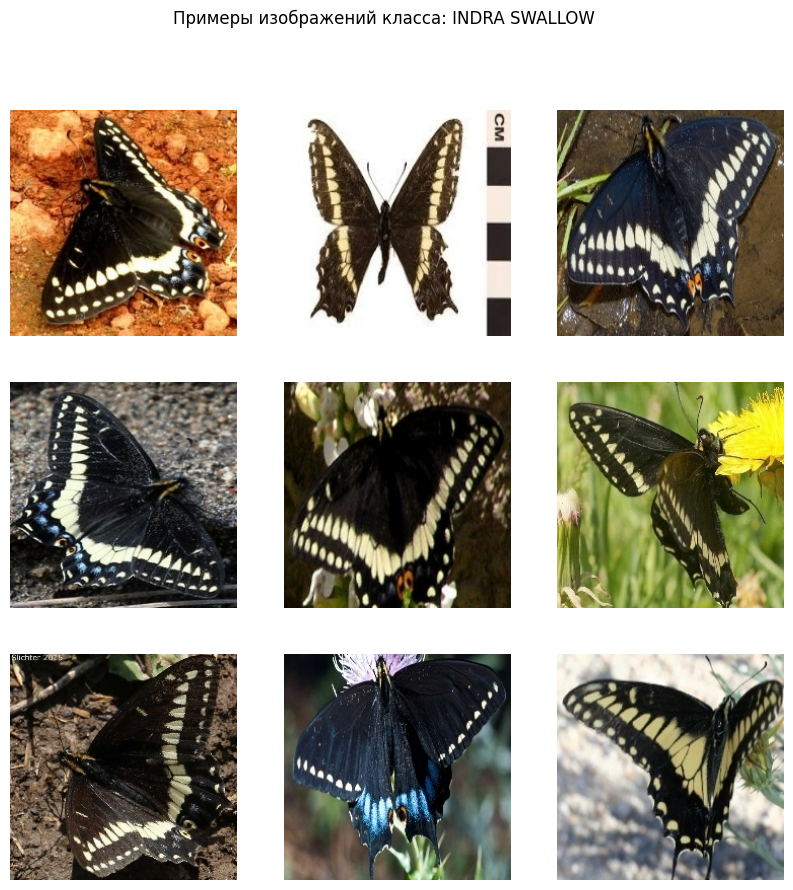

In [32]:
class_name = random.choice(list(os.listdir(TRAIN_DIR)))
class_path = os.path.join(TRAIN_DIR, class_name)
images = os.listdir(class_path)[:9]

plt.figure(figsize=(10,10))
for i, img_name in enumerate(images):
    img = Image.open(os.path.join(class_path, img_name))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle(f"Примеры изображений класса: {class_name}")
plt.show()

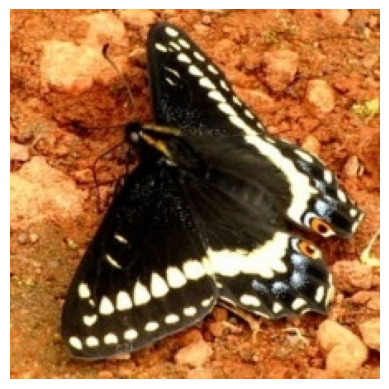

In [33]:
tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

img_path = os.path.join(class_path, images[0])

img = tfms(Image.open(img_path))

plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()
